In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

from src.langgraph_basics.Sequential_Agents import graph

In [3]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [6]:
def adder(state: AgentState) -> AgentState:
    """Adds the numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """Subtracts the numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state: AgentState) -> str:
    """Decide which node to go next"""
    if state['operation'] == "+":
        return "addition_operation"
    return "subtraction_operation"


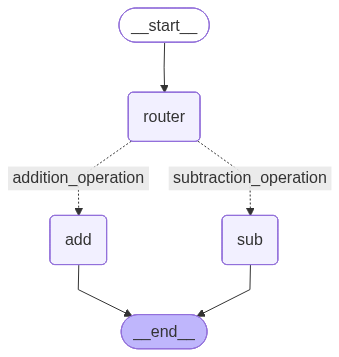

In [7]:
graph = StateGraph(AgentState)

graph.add_node("add", adder)
graph.add_node("sub", subtractor)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge: Node
        "addition_operation": "add",
        "subtraction_operation": "sub"
    }
)

graph.add_edge("add", END)
graph.add_edge("sub", END)

app = graph.compile()

app

In [11]:
add_state = AgentState(number1=1, operation="+", number2=4)
sub_state = AgentState(number1=5, operation="-", number2=4)

In [12]:
print(app.invoke(add_state))

{'number1': 1, 'operation': '+', 'number2': 4, 'finalNumber': 5}


In [13]:
print(app.invoke(sub_state))

{'number1': 5, 'operation': '-', 'number2': 4, 'finalNumber': 1}
